In [1]:
from sklearn.preprocessing import StandardScaler
from utils.evaluation import *
from utils.load_data import load_processed_data
from models.dnn import DNN
from models.linear_regression import LinearRegressionSklearn 
import torch
from torch.utils.data import DataLoader, Dataset

## Load data

In [2]:
data_path = '../data/processed'
X_train, X_val, X_test, y_train, y_val, y_test = load_processed_data(data_path)

X_train shape: torch.Size([2437, 30]), y_train shape: torch.Size([2437, 1])
X_val shape: torch.Size([305, 30]), y_val shape: torch.Size([305, 1])
X_test shape: torch.Size([305, 30]), y_test shape: torch.Size([305, 1])


In [3]:
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [4]:
batch_size = 64

train_dataset = CustomDataset(X_train, y_train)
val_dataset = CustomDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

## Training and Evaluation

#### Hyperparameters

In [5]:
epochs = 500
patience = 30
early_stopping = True
grad_clip = True

activation = 'leaky_relu'
learning_rate = 0.01
batch_norm = True
dropout = 0.0
l2_lambda = 0.0
weight_decay = 0.0
momentum = 0.9

architectures = {
    'DNN-16': [16],
    'DNN-30-8': [30, 8],
    'DNN-30-16-8': [30, 16, 8],
    'DNN-30-16-8-4': [30, 16, 8, 4],
    'DNN-Custom': [64, 32, 16, 8]
}

In [6]:
def pipeline(
        model, 
        epochs=50, 
        verbose=True, 
        early_stopping=True, 
        patience=40, 
        grad_clip=True, 
        title=None,
):
    train_losses, val_losses = model.fit(
        train_loader, 
        val_loader, 
        epochs=epochs, 
        verbose=verbose, 
        early_stopping=early_stopping, 
        patience=patience, 
        grad_clip=grad_clip
    )
    test_model(model, X_test, y_test)
    if title is None:
        title = f'{model.__class__.__name__}'
    plot_loss(train_losses, val_losses, log=True, title=title)

### Linear Regression

In [7]:
lr = LinearRegressionSklearn()
lr.fit(X_train, y_train)
test_model(lr, X_test, y_test)


=========== Model Evaluation ===========
Mean Absolute Error (MAE): 10.3989
Mean Squared Error (MSE): 188.0139
R^2 Score: 0.7751


### DNN-16

In [8]:
dnn_16 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=architectures['DNN-16'],
    output_dim=1,
    lr=learning_rate,
    dropout=dropout,
    batch_norm=batch_norm,
    l2_lambda=l2_lambda,
    activation=activation, 
    weight_decay=weight_decay,
    momentum=momentum,
)
dnn_16.model

Sequential(
  (0): Linear(in_features=30, out_features=16, bias=True)
  (1): LeakyReLU(negative_slope=0.01)
  (2): Linear(in_features=16, out_features=1, bias=True)
)

Epoch [50/500], Train Loss: 118.4819, Val Loss: 152.6823
Early stopping at epoch 98

=========== Model Evaluation ===========
Mean Absolute Error (MAE): 8.6855
Mean Squared Error (MSE): 137.2737
R^2 Score: 0.8358


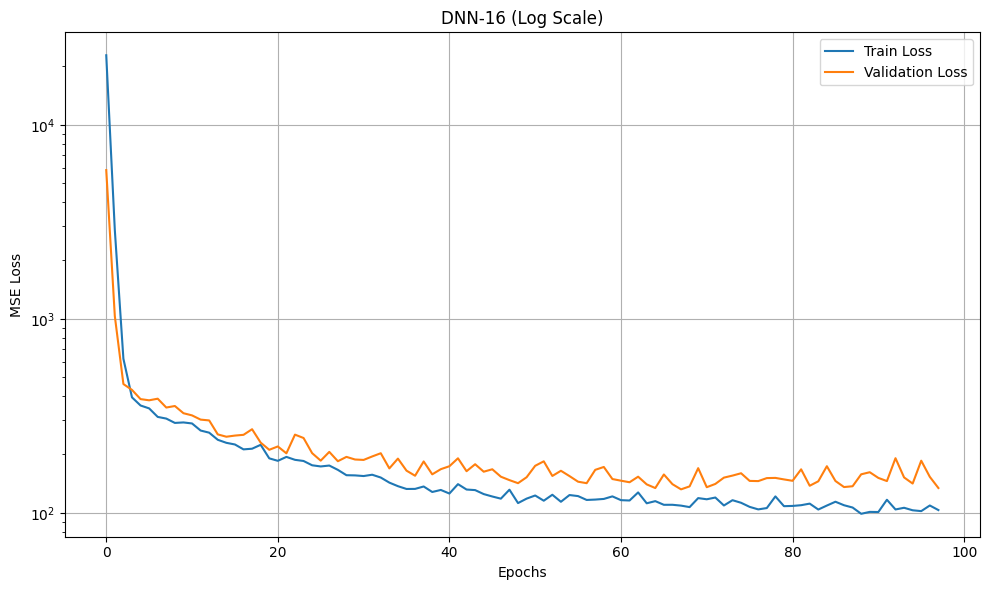

In [9]:
pipeline(dnn_16, epochs=epochs, early_stopping=early_stopping, patience=patience, title='DNN-16')

## DNN-30-8

In [10]:
dnn_30_8 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=architectures['DNN-30-8'],
    output_dim=1,
    lr=learning_rate,
    dropout=dropout,
    batch_norm=batch_norm,
    l2_lambda=l2_lambda,
    activation=activation,
    weight_decay=weight_decay,
    momentum=momentum,
)
dnn_30_8.model

Sequential(
  (0): Linear(in_features=30, out_features=30, bias=True)
  (1): LeakyReLU(negative_slope=0.01)
  (2): Linear(in_features=30, out_features=8, bias=True)
  (3): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (4): LeakyReLU(negative_slope=0.01)
  (5): Linear(in_features=8, out_features=1, bias=True)
)

Epoch [50/500], Train Loss: 116.1416, Val Loss: 186.5501
Epoch [100/500], Train Loss: 84.2272, Val Loss: 255.7577
Early stopping at epoch 134

=========== Model Evaluation ===========
Mean Absolute Error (MAE): 8.6581
Mean Squared Error (MSE): 136.9044
R^2 Score: 0.8362


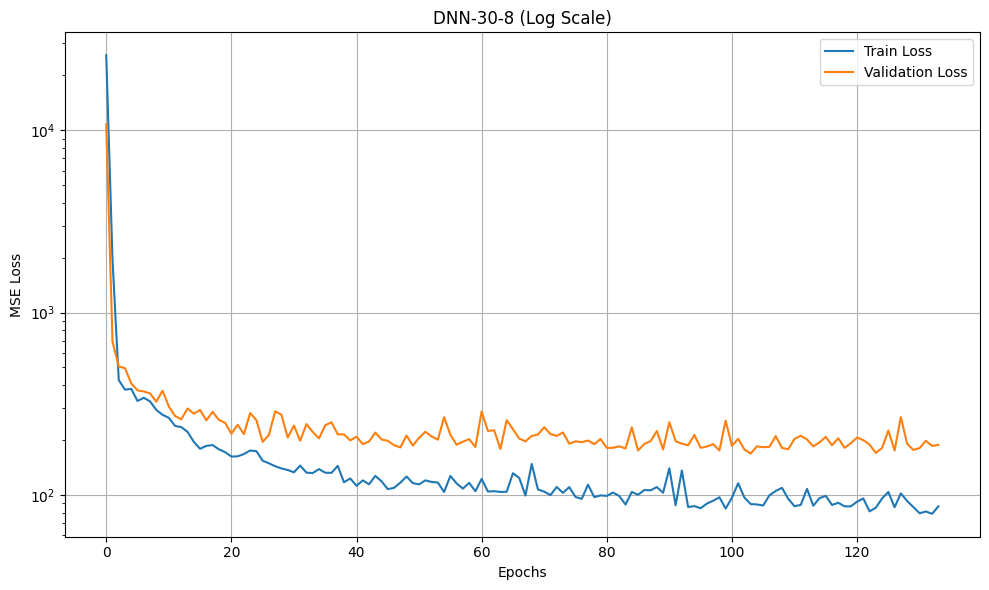

In [11]:
pipeline(dnn_30_8, epochs=epochs, early_stopping=early_stopping, patience=patience, title='DNN-30-8')

## DNN-30-16-8

In [12]:
dnn_30_16_8 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=architectures['DNN-30-16-8'],
    output_dim=1,
    lr=learning_rate,
    dropout=dropout,
    batch_norm=batch_norm,
    l2_lambda=l2_lambda,
    activation=activation,
    weight_decay=weight_decay,
    momentum=momentum,
)

Epoch [50/500], Train Loss: 102.6632, Val Loss: 256.0483
Early stopping at epoch 99

=========== Model Evaluation ===========
Mean Absolute Error (MAE): 8.7548
Mean Squared Error (MSE): 131.1557
R^2 Score: 0.8431


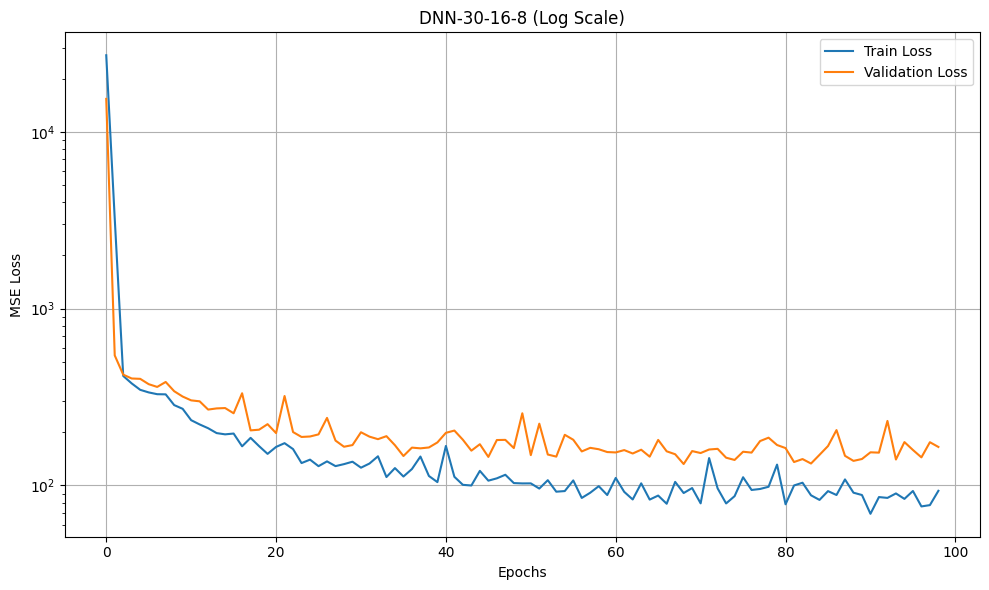

In [13]:
pipeline(dnn_30_16_8, epochs=epochs, early_stopping=early_stopping, patience=patience, title='DNN-30-16-8')

## DNN-30-16-8-4

In [14]:
dnn_30_16_8_4 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=architectures['DNN-30-16-8-4'],
    output_dim=1,
    lr=learning_rate,
    dropout=dropout,
    batch_norm=batch_norm,
    l2_lambda=l2_lambda,
    activation=activation,
    weight_decay=weight_decay,
    momentum=momentum,
)

Epoch [50/500], Train Loss: 101.8834, Val Loss: 207.5123
Epoch [100/500], Train Loss: 73.9633, Val Loss: 140.9590
Epoch [150/500], Train Loss: 64.0662, Val Loss: 173.1772
Early stopping at epoch 151

=========== Model Evaluation ===========
Mean Absolute Error (MAE): 8.5836
Mean Squared Error (MSE): 126.5061
R^2 Score: 0.8487


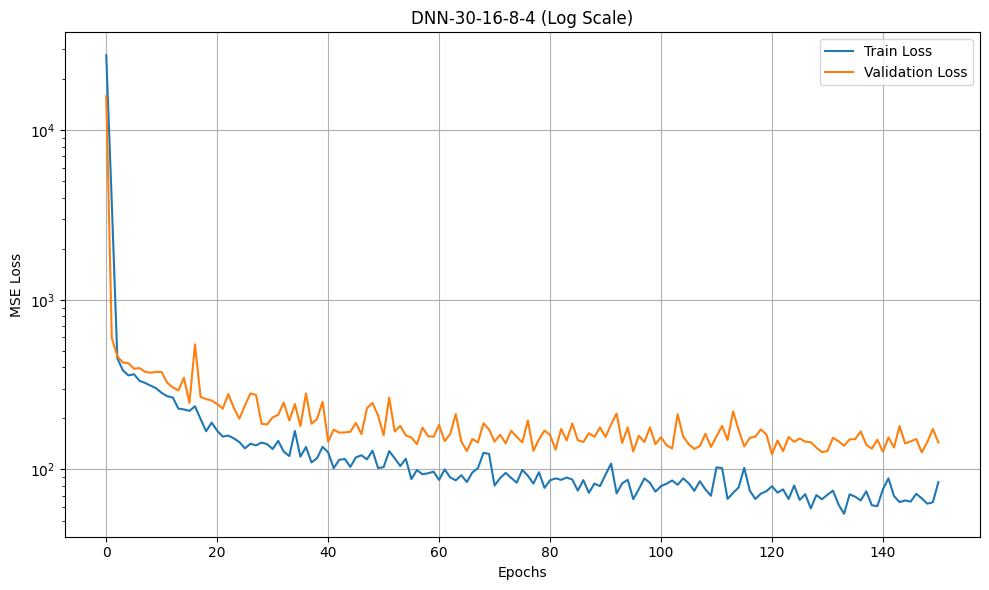

In [15]:
pipeline(dnn_30_16_8_4, epochs=epochs, early_stopping=early_stopping, patience=patience, title='DNN-30-16-8-4')

## Custom DNN

In [16]:
custom_dnn = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=architectures['DNN-Custom'],
    output_dim=1,
    lr=learning_rate,
    dropout=dropout,
    batch_norm=batch_norm,
    l2_lambda=l2_lambda,
    activation=activation,
    weight_decay=weight_decay,
    momentum=momentum,
)

Epoch [50/500], Train Loss: 106.1851, Val Loss: 216.8432
Epoch [100/500], Train Loss: 63.7053, Val Loss: 172.3246
Epoch [150/500], Train Loss: 44.1594, Val Loss: 178.7857
Early stopping at epoch 161

=========== Model Evaluation ===========
Mean Absolute Error (MAE): 9.1394
Mean Squared Error (MSE): 150.2453
R^2 Score: 0.8203


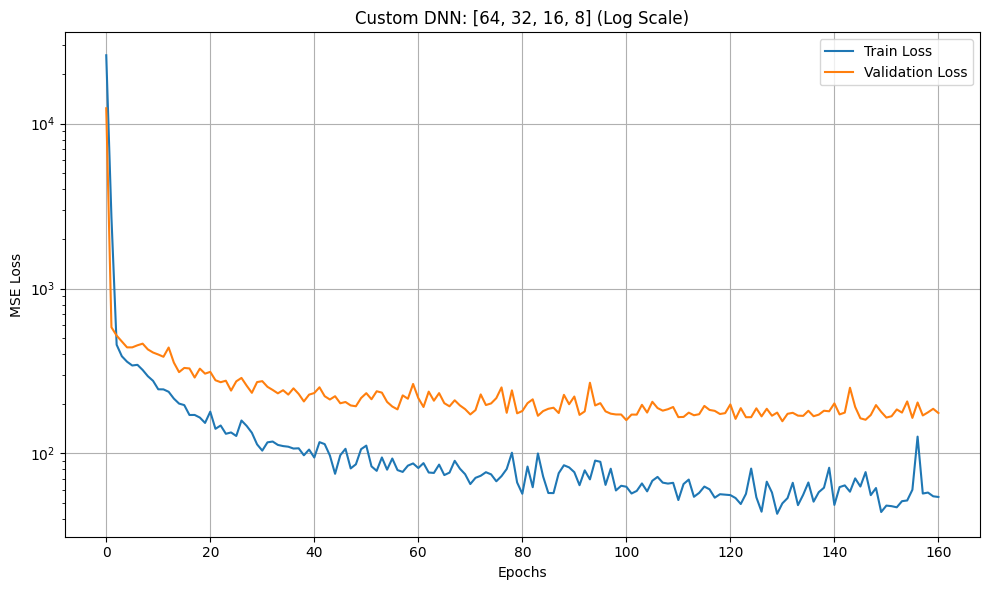

In [17]:
pipeline(custom_dnn, epochs=epochs, early_stopping=early_stopping, patience=patience, title='Custom DNN: [64, 32, 16, 8]')